In [34]:
# Load necessary libraries
import os
import pandas as pd
from pathlib import Path

In [37]:
# Randomly pick three people from the E-Mail dataset
poi = ["arnold-j", "benson-r", "lavorato-j", "scott-s"]
print(poi)
# Pick two folders from the E-Mail dataset I think are interesting to explore
foi = ["inbox", "sent"]
print(foi)
# Get the current working directory
cur_dir = "/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir"
print(cur_dir)
# Create a list to store the file paths of the selected E-Mails
email_file_paths = [f"{cur_dir}/{person}/{folder}" for folder in foi for person in poi]
print(email_file_paths)


['arnold-j', 'benson-r', 'lavorato-j', 'scott-s']
['inbox', 'sent']
/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir
['/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/arnold-j/inbox', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/benson-r/inbox', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/lavorato-j/inbox', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/scott-s/inbox', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/arnold-j/sent', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/benson-r/sent', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/lavorato-j/sent', '/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/scott-s/sent']


In [40]:
# iterate through the files in the selected folder and rename them to have a .txt extension
# go through throught index 0-8 to treat all folders
#folder = Path(email_file_paths[8])
#
#for file in folder.iterdir():
#    if file.is_file() and file.suffix == "":
#        new_name = file.with_suffix(".txt")
#        file.rename(new_name)
#        print(f"Renamed {file.name} to {new_name.name}")
        
        
# Create a list to store the file paths of the selected E-Mails
folder_arnold_inbox = Path(email_file_paths[0])
folder_benson_inbox = Path(email_file_paths[1])
folder_lavorato_inbox = Path(email_file_paths[2])
folder_scott_inbox = Path(email_file_paths[3])

folder_arnold_sent = Path(email_file_paths[4])
folder_benson_sent = Path(email_file_paths[5])
folder_lavorato_sent = Path(email_file_paths[6])
folder_scott_sent = Path(email_file_paths[7])


print(folder_lavorato_inbox)
print(folder_lavorato_sent)

/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/lavorato-j/inbox
/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/raw/maildir/lavorato-j/sent


In [42]:
import re
# Create a list to store the file paths of the selected E-Mails and their corresponding labels
def load_raw_emails(folder_path):
    emails = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):
            with open(os.path.join(folder_path, filename), "r", encoding="latin1") as f:
                emails.append((filename, f.read()))
    return emails


# split header from body
def split_header_body(raw_text):
    parts = raw_text.split("\n\n", 1)
    if len(parts) == 2:
        header, body = parts
    else:
        header, body = parts[0], ""
    return header, body

# Parse the headers into a dictionary
def parse_headers(header_text):
    headers = {}
    for line in header_text.split("\n"):
        if ":" in line:
            key, value = line.split(":", 1)
            headers[key.strip()] = value.strip()
    return headers

# Clean the body text by removing quoted text and reducing multiple newlines
def clean_body(text):
    # Zitatblöcke entfernen
    text = re.sub(r"(?m)^>.*$", "", text)
    # Mehrfache Leerzeilen reduzieren
    text = re.sub(r"\n\s*\n", "\n\n", text)
    return text.strip()

# Pack everything into a DataFrame
def build_email_dataframe(folder_path):
    rows = []
    for filename, raw_text in load_raw_emails(folder_path):
        header_text, body_text = split_header_body(raw_text)
        body_text = clean_body(body_text)
        headers = parse_headers(header_text)

        rows.append({
            "file": filename,
            "message_id": headers.get("Message-ID"),
            "date": headers.get("Date"),
            "sender": headers.get("From"),
            "receiver": headers.get("To"),
            "subject": headers.get("Subject"),
            "body": body_text.strip()
        })

    return pd.DataFrame(rows)

arnold_inbox_df = build_email_dataframe(folder_arnold_inbox)
arnold_sent_df = build_email_dataframe(folder_arnold_sent)

benson_inbox_df = build_email_dataframe(folder_benson_inbox)
benson_sent_df = build_email_dataframe(folder_benson_sent)

scott_inbox_df = build_email_dataframe(folder_scott_inbox)
scott_sent_df = build_email_dataframe(folder_scott_sent)

lavorato_inbox_df = build_email_dataframe(folder_lavorato_inbox)
lavorato_sent_df = build_email_dataframe(folder_lavorato_sent)

arnold_inbox_df.head()


arnold_inbox_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_inbox.csv")
arnold_sent_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_sent.csv")

benson_inbox_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_inbox.csv")
benson_sent_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_sent.csv")

scott_inbox_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_inbox.csv")
scott_sent_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_sent.csv")

lavorato_inbox_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_inbox.csv")
lavorato_sent_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_sent.csv")


In [43]:
arnold_inbox_df.head()

,file,message_id,date,sender,receiver,subject,body
0,29.txt,<8952460.1075852727564.JavaMail.evans@thyme>,"Mon, 22 Oct 2001 05:35:09 -0700 (PDT)",swl@winelibrary.com,jarnold@enron.com,"3 announcements-Tasting,Catalog,Big Sale!!!",To Place an order . . .\nPLEASE CALL 973-376-0...
1,15.txt,<18157209.1075852727209.JavaMail.evans@thyme>,"Thu, 27 Sep 2001 06:24:25 -0700 (PDT)",louise.kitchen@enron.com,c..bland@enron.com,FW: Fantastic Friday/Super Saturday Interviewers,"Ted,\n\nThe people included in the cc: are tho..."
2,100.txt,<29857442.1075855217959.JavaMail.evans@thyme>,"Tue, 1 Jan 2002 11:04:18 -0800 (PST)",msagel@home.com,jarnold@enron.com,Market update,Happy New Year and best wishes.\n - Energy0101...
3,14.txt,<26959222.1075852727174.JavaMail.evans@thyme>,"Tue, 25 Sep 2001 09:58:17 -0700 (PDT)",frank.hayden@enron.com,"jim.schwieger@enron.com, mike.grigsby@enron.co...",Trade idea,Front to backs are huge\nIs the delivered basi...
4,28.txt,<1533810.1075852727541.JavaMail.evans@thyme>,"Fri, 19 Oct 2001 06:13:34 -0700 (PDT)",kislince@er.oge.com,jarnold@enron.com,FW: Enron Deal from 17-Oct-01,"John,\n\nWill you advise if you have completed..."


Now we go ahead and start to analyze the structured data

In [45]:
import spacy
# Load the large English model for better entity recognition
nlp = spacy.load('en_core_web_lg')

def extract_entities(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_
        })
    return entities


# If we want to focus on specific types of entities, we can filter them as follows:
def extract_relevant_entities(text):
    doc = nlp(text)
    relevant = []
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE"]:
            relevant.append({
                "entity": ent.text,
                "type": ent.label_
            })
    return relevant


# Now we want to apply this function to the body of EACH email in the DataFrame and store the results in a new column
def extract_entities_for_df(df):
    all_entities = []

    for idx, row in df.iterrows():
        ents = extract_relevant_entities(row["body"])
        for e in ents:
            all_entities.append({
                "email_id": row["file"],
                "entity": e["entity"],
                "type": e["type"]
            })

    return pd.DataFrame(all_entities)

# clean the extracted entities by converting them to uppercase and stripping whitespace, then save to CSV
def clean_entities_df(df):
    # 1) Check if the column "entity" exists in my DataFrame
    if "entity" not in df.columns:
        raise KeyError("The column 'entity' does not exist in the DataFrame.")

    # 2) Check if the column is completely empty
    if df["entity"].isna().all() or (df["entity"].astype(str).str.strip() == "").all():
        raise ValueError("The column 'entity' is empty or contains only empty values.")

    # 3) Perform cleaning
    df["entity_clean"] = (
        df["entity"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.upper()
    )

    return df




# Apply the entity extraction to the inbox DataFrame of Arnold
arnold_inbox_entities_df = extract_entities_for_df(arnold_inbox_df)
arnold_inbox_entities_df = clean_entities_df(arnold_inbox_entities_df)
arnold_inbox_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_inbox_entities.csv")

arnold_sent_entities_df = extract_entities_for_df(arnold_sent_df)
arnold_sent_entities_df = clean_entities_df(arnold_sent_entities_df)
arnold_sent_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_sent_entities.csv")

benson_inbox_entities_df = extract_entities_for_df(benson_inbox_df)
benson_inbox_entities_df = clean_entities_df(benson_inbox_entities_df)
benson_inbox_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_inbox_entities.csv")

benson_sent_entities_df = extract_entities_for_df(benson_sent_df)
benson_sent_entities_df = clean_entities_df(benson_sent_entities_df)
benson_sent_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_sent_entities.csv")

lavorato_inbox_entities_df = extract_entities_for_df(lavorato_inbox_df)
lavorato_inbox_entities_df = clean_entities_df(lavorato_inbox_entities_df)
lavorato_inbox_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_inbox_entities.csv")

lavorato_sent_entities_df = extract_entities_for_df(lavorato_sent_df)
lavorato_sent_entities_df = clean_entities_df(lavorato_sent_entities_df)
lavorato_sent_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_sent_entities.csv")

scott_inbox_entities_df = extract_entities_for_df(scott_inbox_df)
scott_inbox_entities_df = clean_entities_df(scott_inbox_entities_df)
scott_inbox_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_inbox_entities.csv")

scott_sent_entities_df = extract_entities_for_df(scott_sent_df)
scott_sent_entities_df = clean_entities_df(scott_sent_entities_df)
scott_sent_entities_df.to_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_sent_entities.csv")

Let's start to do a bit of explorative data analysis. Who is now the most abundant Person or Place for Arnold, Benson, Lavorato and Scott?

In [ ]:
arnold_inbox_entities_df.groupby("entity_clean")["email_id"].count().sort_values(ascending=False).head(20)


entity_clean
ENRON                           958
HOUSTON                          88
DOW JONES & COMPANY, INC.        82
DYNEGY                           80
NEW YORK                         70
JOHN                             58
ENRON CORP.                      49
U.S.                             41
THE WALL STREET JOURNAL          40
MOODY'S                          34
FASTOW                           33
ARNOLD                           29
BLOOMBERG                        27
REUTERS ENGLISH NEWS SERVICE     26
MICROSOFT                        24
ANDREW FASTOW                    23
FRANK                            22
REUTERS                          21
US                               19
LAY                              18
Name: email_id, dtype: int64

In [ ]:
benson_inbox_entities_df.groupby("entity_clean")["email_id"].count().sort_values(ascending=False).head(20)


entity_clean
JOHN ARNOLD/HOU                      511
JOHN                                 212
ENRON                                188
NYMEX                                 76
EOL                                   74
CALIFORNIA                            58
OTMC                                  54
JOHN ARNOLD                           53
JENNIFER FRASER                       52
MARGARET                              51
ARNOLD                                51
CARR FUTURES                          47
HOUSTON                               46
JOHN SENT                             43
EVA PAO                               40
U.S.                                  37
JEN FRASER                            35
ENRON GLOBAL MARKETS FUNDAMENTALS     32
ANDY                                  32
PAINEWEBBER                           30
Name: email_id, dtype: int64

In [ ]:
scott_inbox_entities_df.groupby("entity_clean")["email_id"].count().sort_values(ascending=False).head(20)   

entity_clean
ENRON                           3461
HOUSTON                          419
DOW JONES & COMPANY, INC.        378
DYNEGY                           354
ARNOLD                           312
U.S.                             306
NEW YORK                         292
ENRON CORP.                      249
LONDON                           223
REUTERS                          187
JOHN SENT                        182
CALIFORNIA                       175
SEC                              165
INDIA                            164
FASTOW                           161
BLOOMBERG                        129
ALLEN                            126
REUTERS ENGLISH NEWS SERVICE     121
TAHOMA                           119
VERDANA                          115
Name: email_id, dtype: int64

Let's build a network graph of the top 20 entities for each person in their inboxes. We will use the NetworkX library to create the graph and Matplotlib to visualize it.

In [46]:
import networkx as nx
from itertools import combinations

def build_entity_graph(entities_df):
    G = nx.Graph()

    for email_id, group in entities_df.groupby("email_id"):
        persons = group[group["type"] == "PERSON"]["entity_clean"].unique()
        for a, b in combinations(persons, 2):
            if G.has_edge(a, b):
                G[a][b]["weight"] += 1
            else:
                G.add_edge(a, b, weight=1)

    return G



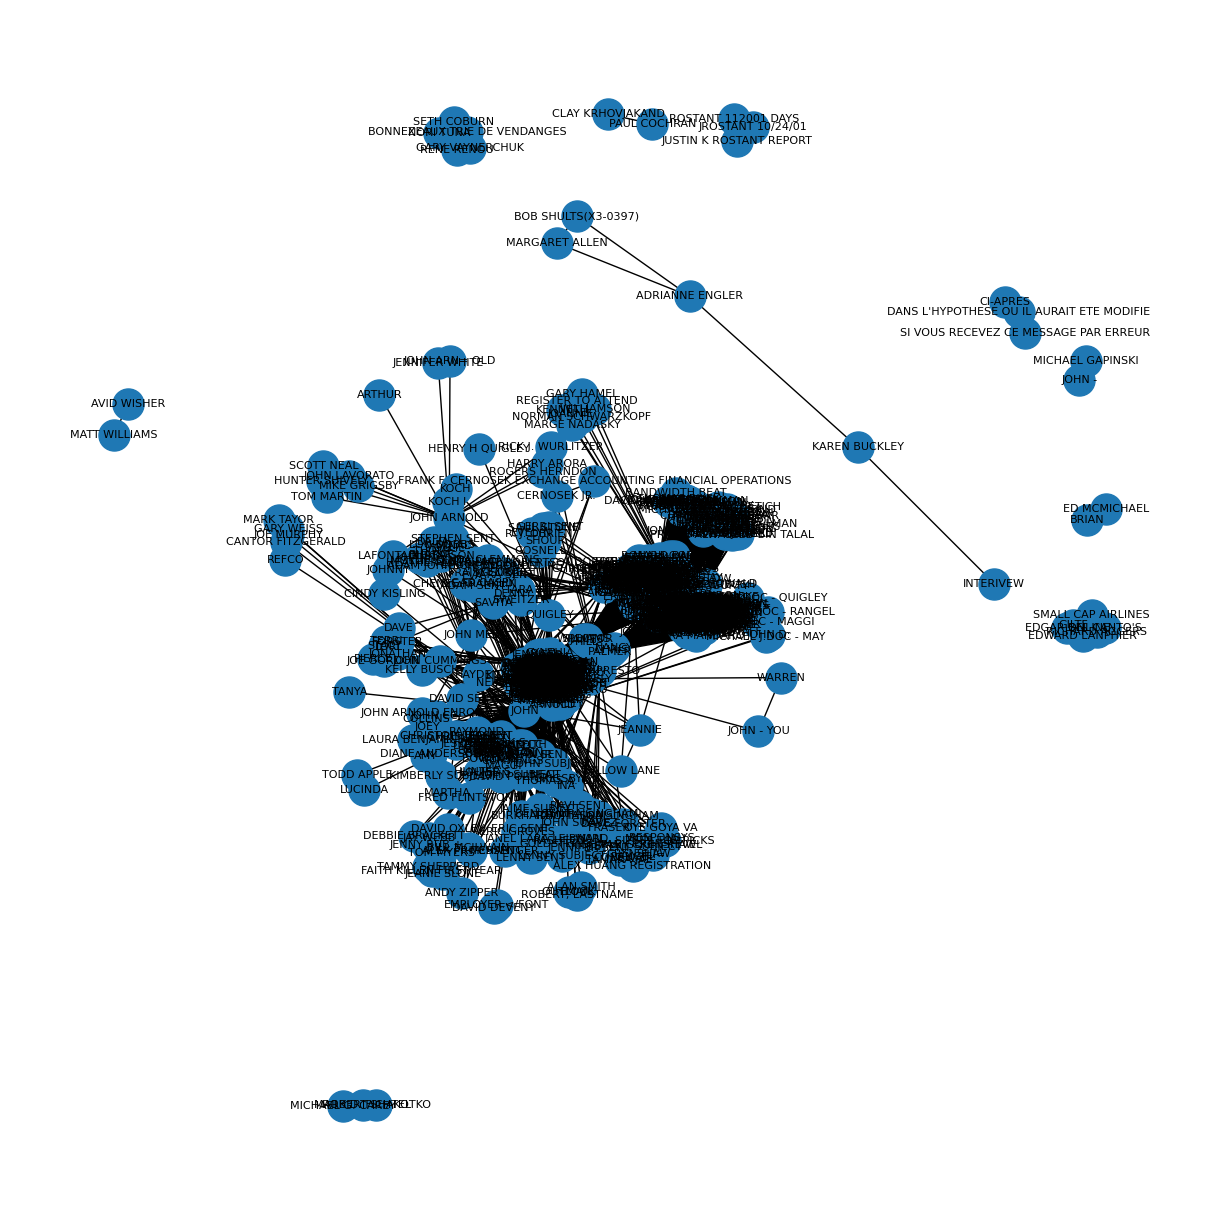

In [47]:
import matplotlib.pyplot as plt

arnold_inbox_graph = build_entity_graph(arnold_inbox_entities_df)
plt.figure(figsize=(12, 12))
nx.draw(arnold_inbox_graph, with_labels=True, node_size=500, font_size=8)
plt.show()


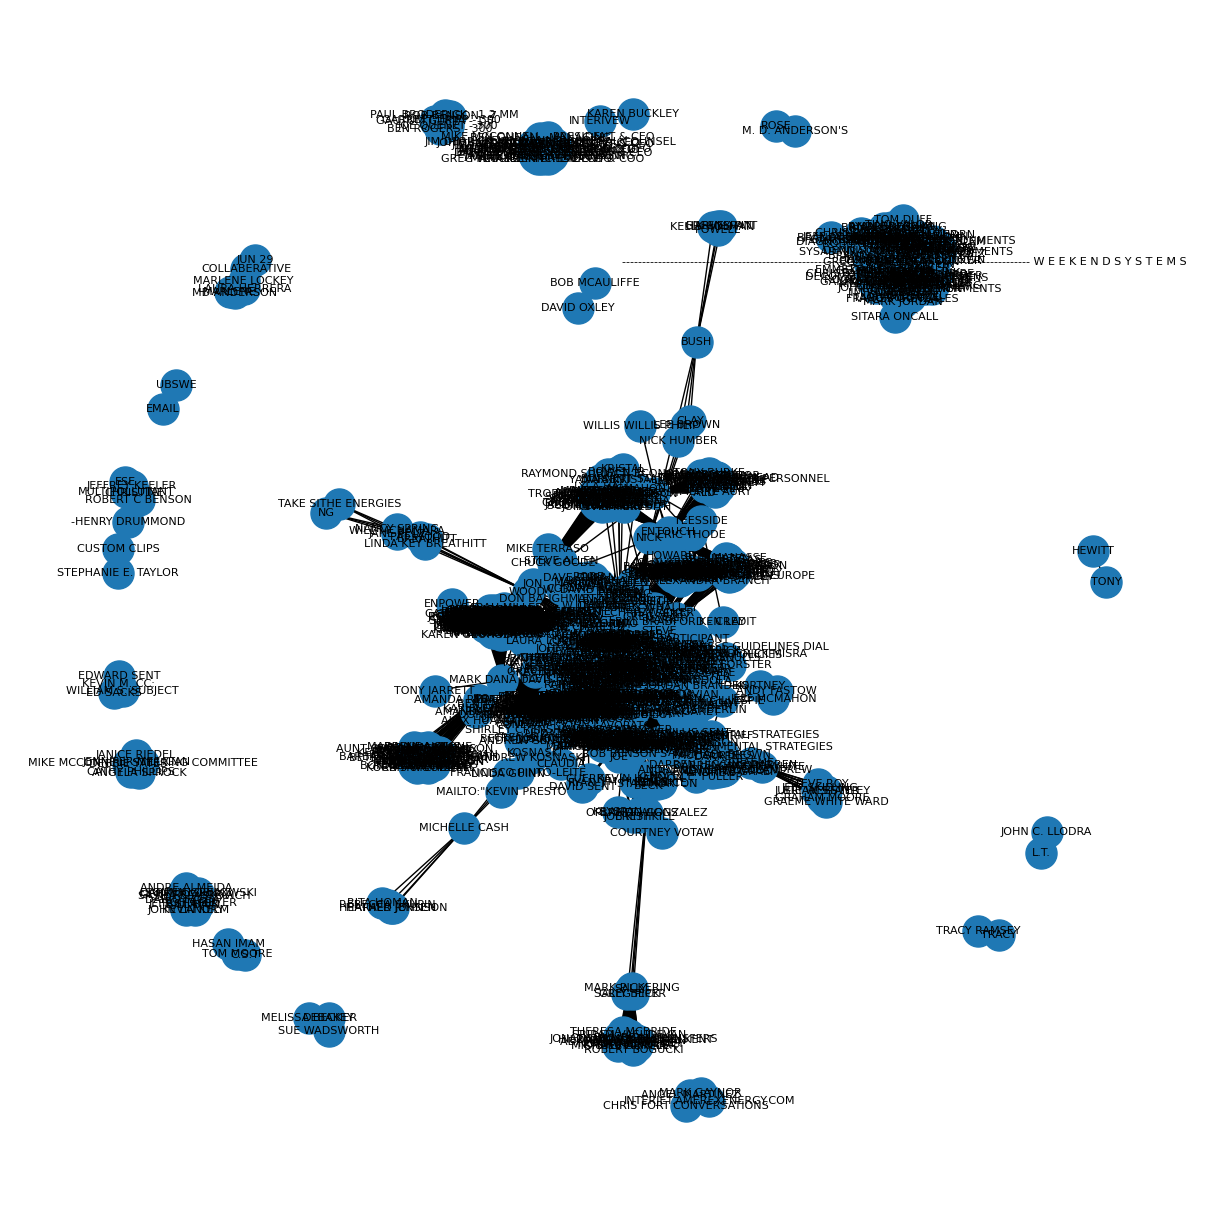

In [48]:
benson_inbox_graph = build_entity_graph(benson_inbox_entities_df)
plt.figure(figsize=(12, 12))
nx.draw(benson_inbox_graph, with_labels=True, node_size=500, font_size=8)
plt.show()

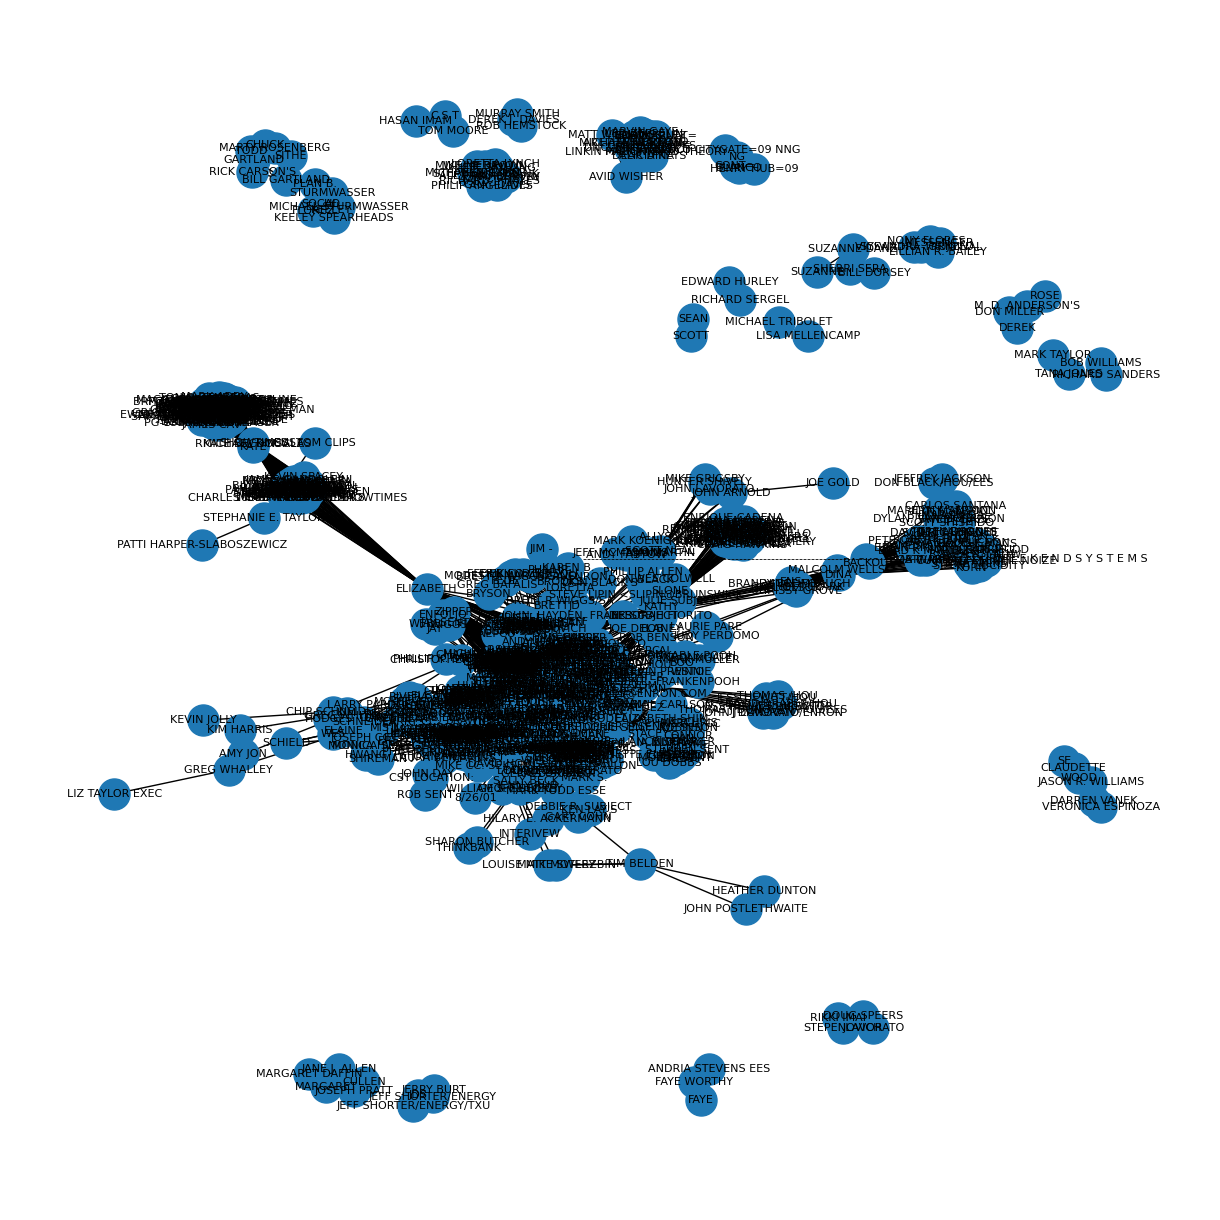

In [49]:
lavorato_inbox_graph = build_entity_graph(lavorato_inbox_entities_df)
plt.figure(figsize=(12, 12))
nx.draw(lavorato_inbox_graph, with_labels=True, node_size=500, font_size=8)
plt.show()

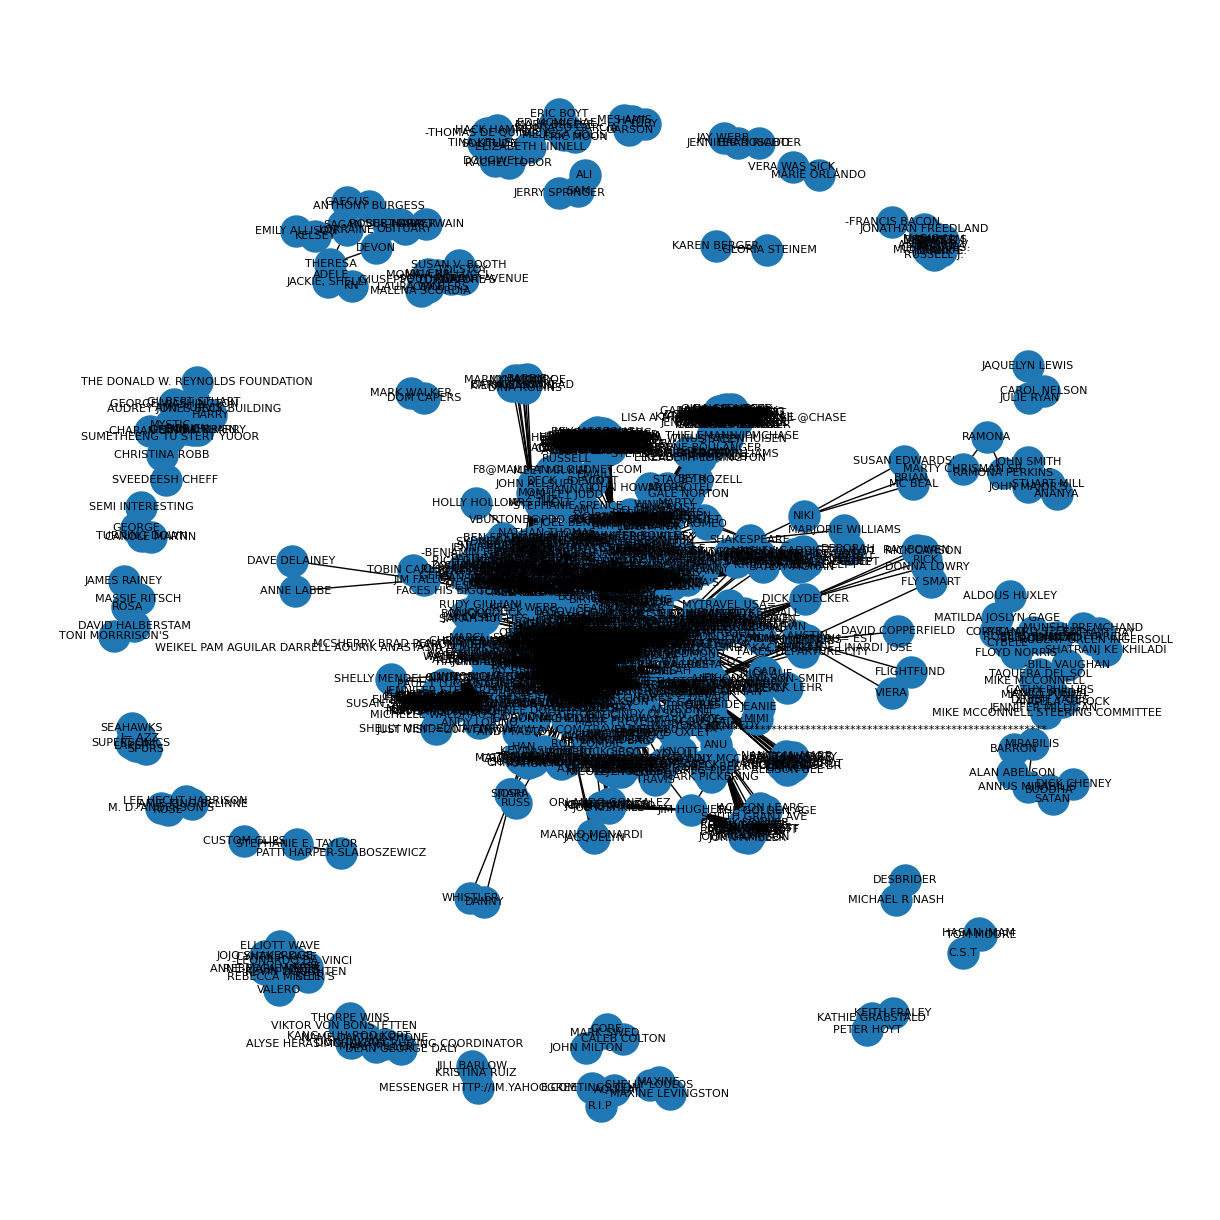

In [50]:
scott_inbox_graph = build_entity_graph(scott_inbox_entities_df)
plt.figure(figsize=(12, 12))
nx.draw(scott_inbox_graph, with_labels=True, node_size=500, font_size=8)
plt.show()